In [1]:
import numpy as np
import matplotlib.pyplot as plt

The following notebook contains numerical analysis of the Lorenz System's fixed points. The fixed points are calculated for the conventional values of $\beta = \frac{8}{3}$ and $\sigma = 10$ with $\rho$ being varied from 1.01 to 30. Each time, the Jacobian for the system is calculated and then its eigenvalues are found.

In [2]:
#Adapting code I wrote for Rossler system
#Defining Lorenz parameters
sigma = 10
beta = 8/3
rho = np.linspace(1.01,30,1001)
x_plus = np.zeros(len(rho))
y_plus = np.zeros(len(rho))
z_plus = np.zeros(len(rho))
A_plus = np.zeros((len(rho),3,3))
eigenvals_plus = np.zeros((len(rho),3), dtype = complex)
eigenvec_plus = np.zeros ((len(rho),3,3), dtype = complex)
for i in range (len(rho)):
    #Updating fixed points
    x_plus[i] = np.sqrt(beta*(rho[i]-1))
    y_plus[i] = x_plus[i]
    z_plus[i] = rho[i]-1
    
    #Calculating eigenvalues,eigenvectors
    A_plus[i] = np.array ([[-sigma,sigma,0],
         [1,-1,-x_plus[i]],
         [x_plus[i],x_plus[i],-beta]])
    eigenvals_plus[i,:],eigenvec_plus[i] = np.linalg.eig(A_plus[i])

In order to identify where the system's behaviour changes, the cells below identify where the real parts of the eigenvalues start to become poisitve and where they start to have imaginary parts. These changes correspond to the system undergoing a Hopf bifurcation and the two fixed points of the system turning from stable nodes into stable foci respectively.

In [3]:
#Calculating where eigenvalues become negative
for i in range(len(rho)):
    if eigenvals_plus[i,0]>0 :
        print(f"system positive until rho={rho[i]}")
        break
    elif eigenvals_plus[i,1]>0 :
        print(f"system positive until rho={rho[i]}")
        break
    elif eigenvals_plus[i,2]>0 : 
        print(f"system positive until rho={rho[i]}")
        break

system positive until rho=24.75281


In [4]:
#Calculating when eigenvalues will start to have complex parts
imag_parts = np.imag(eigenvals_plus)
for i in range(len(rho)):
    if any(imag_parts[i,:])!=0 :
        print(f"system real until rho={rho[i]}")
        break

system real until rho=1.35788


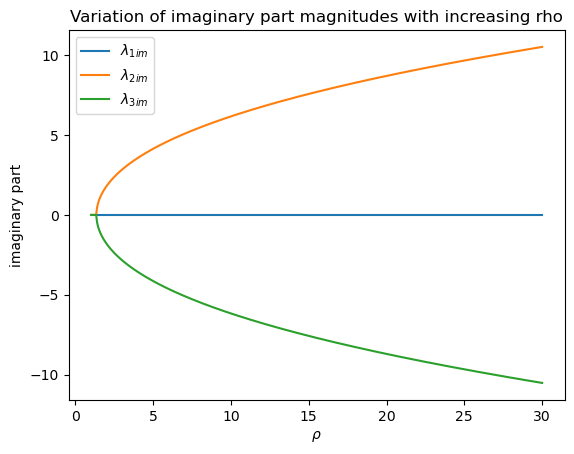

In [5]:
#Plotting imaginary parts 
plt.plot(rho,imag_parts[:,0],label = r"$\lambda_{1 im}$")
plt.plot(rho,imag_parts[:,1],label = r"$\lambda_{2 im}$")
plt.plot(rho,imag_parts[:,2],label = r"$\lambda_{3 im}$")
plt.xlabel(r"$\rho$")
plt.ylabel("imaginary part")
plt.title("Variation of imaginary part magnitudes with increasing rho")
plt.legend()

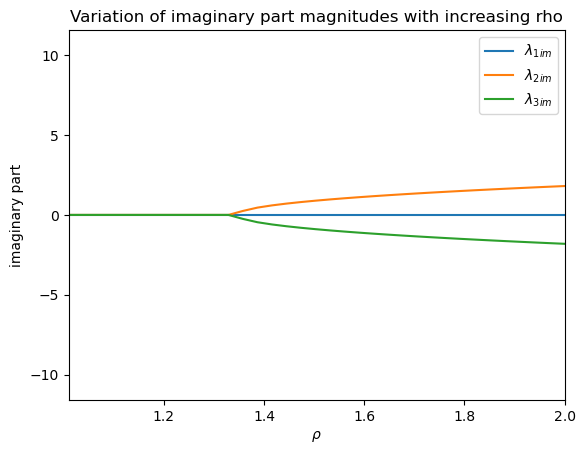

In [6]:
#Zooming in
plt.plot(rho,imag_parts[:,0],label = r"$\lambda_{1 im}$")
plt.plot(rho,imag_parts[:,1],label = r"$\lambda_{2 im}$")
plt.plot(rho,imag_parts[:,2],label = r"$\lambda_{3 im}$")
plt.xlim(1.01,2)
plt.xlabel(r"$\rho$")
plt.ylabel("imaginary part")
plt.title("Variation of imaginary part magnitudes with increasing rho")
plt.legend()